# Visualization Quality Metrics: *Benchmark Data*

This notebook computes Trustworthiness, Continuity, Spearman Correlation, and DEMaP for each dimensionality reduction method (PCA, UMAP, PHATE, PaCMAP) on a given benchmark dataset.

Embeddings and reduced embeddings are loaded from precomputed `.npy` files generated by `eval_pipeline.py`.

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import phate
import pacmap
import umap as umap_pkg
from sklearn.decomposition import PCA as skPCA
from sklearn.manifold import trustworthiness
from sklearn.metrics import pairwise_distances
from sklearn.neighbors import kneighbors_graph
from scipy.sparse.csgraph import shortest_path
from scipy.stats import spearmanr

# navigate to src/ from wherever the notebook is run
current = os.path.abspath('.')
while os.path.basename(current) != 'src' and current != os.path.dirname(current):
    current = os.path.dirname(current)
src_dir = current
os.chdir(src_dir)
sys.path.insert(0, src_dir)

/Applications/anaconda3/envs/phate-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Setup

Change `dataset` to run on a different benchmark. Available options: `rcv1`, `arxiv`, `amazon`, `dbpedia`, `wos`.

In [2]:
# config: change dataset and embedding model here
embedding_model = "sentence-transformers/all-MiniLM-L6-v2"
dataset = "rcv1"  # options: rcv1, arxiv, amazon, dbpedia, wos

embedding_dir = f"{embedding_model}_embeddings"
reduction_dir = f"{embedding_model}_reduced_embeddings"
results_dir = f"{embedding_model}_results"
os.makedirs(results_dir, exist_ok=True)

## 2. Load Embeddings

Load precomputed embeddings from `eval_pipeline.py` output. To generate these, run:

```bash
python src/run_models/benchmark_datasets/eval_pipeline.py --dataset rcv1
```

In [3]:
# load precomputed high-dimensional embeddings
x_high = np.load(f"{embedding_dir}/{dataset}.npy")
print(f"Embeddings shape: {x_high.shape}")

Embeddings shape: (1566, 384)


## 3. Compute 2D Reductions

All four methods are run natively at 2D directly from the high-dimensional embeddings. PCA uses SVD (components ordered by variance). PHATE uses classic MDS (components ordered by eigenvalue). UMAP and PaCMAP are run at `n_components=2` — slicing the first 2 columns of a higher-dimensional embedding is not valid for these methods since they are optimization-based with no component ordering. Large datasets are subsampled to 5000 points before reduction; pairwise distances in the metrics step scale as n², so the same limit applies there. Results are cached in `{embedding_model}_reduced_2d/` for fast re-runs.

In [4]:
reduction_2d_dir = f"{embedding_model}_reduced_2d"
os.makedirs(reduction_2d_dir, exist_ok=True)

# subsample before running 2D reductions — large datasets (e.g. amazon ~60k) are too slow otherwise
# pairwise distances in the metrics step also scale as n^2, so the same limit applies there
max_samples = 5000
if x_high.shape[0] > max_samples:
    np.random.seed(42)
    sub_idx = np.random.choice(x_high.shape[0], max_samples, replace=False)
    x_high_sub = x_high[sub_idx]
    print(f"Subsampled to {max_samples} points for 2D reduction and metrics")
else:
    x_high_sub = x_high
    print(f"No subsampling needed ({x_high.shape[0]} points)")

def load_or_compute_2d(name, path, compute_fn):
    if os.path.exists(path):
        print(f"Loading cached 2D {name} from {path}...")
        return np.load(path)
    print(f"Computing 2D {name}...")
    result = compute_fn()
    np.save(path, result)
    print(f"Saved to {path}")
    return result

suffix = f"{dataset}_sub{len(x_high_sub)}"

reductions = {}

reductions["PCA"] = load_or_compute_2d(
    "PCA", f"{reduction_2d_dir}/PCA_2d_{suffix}.npy",
    lambda: skPCA(n_components=2, random_state=67).fit_transform(x_high_sub)
)
reductions["UMAP"] = load_or_compute_2d(
    "UMAP", f"{reduction_2d_dir}/UMAP_2d_{suffix}.npy",
    lambda: umap_pkg.UMAP(n_components=2, min_dist=0.05, n_neighbors=10, random_state=67).fit_transform(x_high_sub)
)
reductions["PHATE"] = load_or_compute_2d(
    "PHATE", f"{reduction_2d_dir}/PHATE_2d_{suffix}.npy",
    lambda: phate.PHATE(n_jobs=-2, random_state=67, n_components=2, mds="classic").fit_transform(x_high_sub)
)
reductions["PaCMAP"] = load_or_compute_2d(
    "PaCMAP", f"{reduction_2d_dir}/PaCMAP_2d_{suffix}.npy",
    lambda: pacmap.PaCMAP(n_components=2, random_state=67).fit_transform(x_high_sub)
)

for name, arr in reductions.items():
    print(f"{name}: {arr.shape}")

No subsampling needed (1566 points)
Loading cached 2D PCA from sentence-transformers/all-MiniLM-L6-v2_reduced_2d/PCA_2d_rcv1_sub1566.npy...
Loading cached 2D UMAP from sentence-transformers/all-MiniLM-L6-v2_reduced_2d/UMAP_2d_rcv1_sub1566.npy...
Loading cached 2D PHATE from sentence-transformers/all-MiniLM-L6-v2_reduced_2d/PHATE_2d_rcv1_sub1566.npy...
Loading cached 2D PaCMAP from sentence-transformers/all-MiniLM-L6-v2_reduced_2d/PaCMAP_2d_rcv1_sub1566.npy...
PCA: (1566, 2)
UMAP: (1566, 2)
PHATE: (1566, 2)
PaCMAP: (1566, 2)


## 4. Metrics

- **Trustworthiness**: measures whether neighbors in low-dim space were also neighbors in high-dim space (local structure preservation)
- **Continuity**: measures whether neighbors in high-dim space are preserved in low-dim space (reverse of trustworthiness)
- **Spearman Correlation**: rank correlation of raw pairwise Euclidean distances high-dim vs 2D
- **DEMaP** (Moon et al. 2019): Spearman correlation of geodesic distances (k-NN shortest paths) in high-dim vs Euclidean distances in 2D; better captures true manifold structure than raw Euclidean

Trustworthiness and Continuity range from 0 to 1, higher is better. Spearman and DEMaP range from -1 to 1, where 1 is perfect preservation and 0 means no relationship.

In [5]:
def compute_continuity(x_high, x_low, n_neighbors=15):
    n = x_high.shape[0]

    d_high = pairwise_distances(x_high)
    d_low  = pairwise_distances(x_low)
    rank_low = np.argsort(np.argsort(d_low, axis=1), axis=1)

    continuity = 0.0
    for i in range(n):
        neighbors_high = set(np.argsort(d_high[i])[1:n_neighbors+1])
        neighbors_low  = set(np.argsort(d_low[i])[1:n_neighbors+1])
        missing = neighbors_high - neighbors_low
        for j in missing:
            continuity += rank_low[i, j] - n_neighbors

    norm = 2.0 / (n * n_neighbors * (2 * n - 3 * n_neighbors - 1))
    return 1 - norm * continuity

In [6]:
def compute_demap(x_high, x_low_2d, n_neighbors=5):
    # DEMaP: geodesic distances (k-NN shortest path) in high-dim vs Euclidean in 2D
    # Moon et al. 2019 (PHATE paper), k=5 to emphasize local structure
    knn = kneighbors_graph(x_high, n_neighbors=n_neighbors, mode='distance', include_self=False)
    geo = shortest_path(knn, directed=False)

    # replace inf (disconnected pairs) with 1 + max finite distance
    # treats disconnected pairs as maximally far rather than dropping them
    max_finite = np.nanmax(geo[np.isfinite(geo)])
    geo[np.isinf(geo)] = 1 + max_finite

    idx = np.triu_indices(x_high.shape[0], k=1)
    geo_flat = geo[idx]
    euc_flat = pairwise_distances(x_low_2d)[idx]

    return spearmanr(geo_flat, euc_flat)[0]

In [7]:
stats = []

# x_high_sub and reductions are already subsampled and computed natively at 2D in the loading cell above
for name, x_low_2d in reductions.items():
    t_score = trustworthiness(x_high_sub, x_low_2d, n_neighbors=15)
    c_score = compute_continuity(x_high_sub, x_low_2d, n_neighbors=15)

    # spearman correlation of raw pairwise Euclidean distances
    d_high = pairwise_distances(x_high_sub).flatten()
    d_low  = pairwise_distances(x_low_2d).flatten()
    spearman_corr, _ = spearmanr(d_high, d_low)

    # DEMaP: geodesic distances in high-dim vs Euclidean in 2D (Moon et al. 2019)
    # k=5 keeps the graph sparse to preserve manifold structure; disconnected pairs
    # are handled by replacing inf with 1+max finite distance (not dropped)
    print(f"  Computing DEMaP for {name}...")
    demap_score = compute_demap(x_high_sub, x_low_2d, n_neighbors=5)

    stats.append({
        "Method": name,
        "Trustworthiness": round(t_score, 4),
        "Continuity": round(c_score, 4),
        "Spearman Correlation": round(spearman_corr, 4),
        "DEMaP": round(demap_score, 4)
    })
    print(f"{name}: Trustworthiness={t_score:.4f}, Continuity={c_score:.4f}, Spearman={spearman_corr:.4f}, DEMaP={demap_score:.4f}")

pd.DataFrame(stats)

  Computing DEMaP for PCA...
PCA: Trustworthiness=0.7781, Continuity=0.8913, Spearman=0.3965, DEMaP=0.4687
  Computing DEMaP for UMAP...
UMAP: Trustworthiness=0.9563, Continuity=0.9442, Spearman=0.4863, DEMaP=0.6847
  Computing DEMaP for PHATE...
PHATE: Trustworthiness=0.7979, Continuity=0.9035, Spearman=0.3725, DEMaP=0.6453
  Computing DEMaP for PaCMAP...
PaCMAP: Trustworthiness=0.9360, Continuity=0.9333, Spearman=0.4218, DEMaP=0.6514


,Method,Trustworthiness,Continuity,Spearman Correlation,DEMaP
0,PCA,0.7781,0.8913,0.3965,0.4687
1,UMAP,0.9563,0.9442,0.4863,0.6847
2,PHATE,0.7979,0.9035,0.3725,0.6453
3,PaCMAP,0.9360,0.9333,0.4218,0.6514


In [8]:
output_path = os.path.join(results_dir, f"viz_metrics_{dataset}.csv")
pd.DataFrame(stats).to_csv(output_path, index=False)
print(f"Saved to {output_path}")

Saved to sentence-transformers/all-MiniLM-L6-v2_results/viz_metrics_rcv1.csv


## 5. Shepard Diagrams

Compares pairwise distances in the original high-dimensional space against the reduced space. Points close to the red diagonal indicate better global distance preservation.

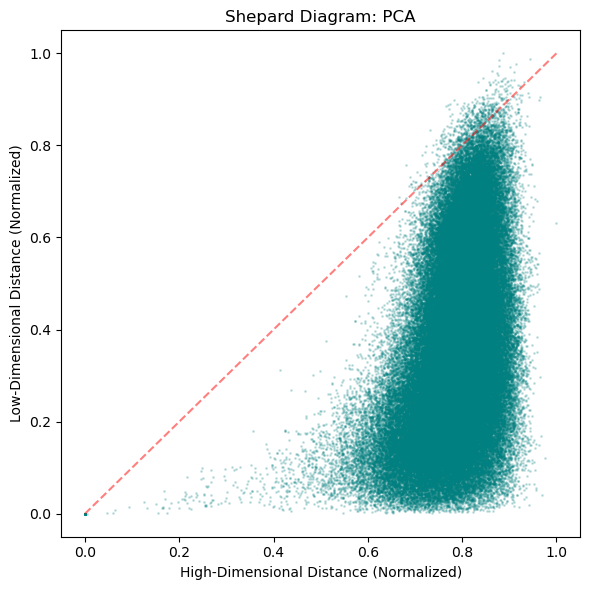

Saved: sentence-transformers/all-MiniLM-L6-v2_results/shepard_rcv1_pca.png


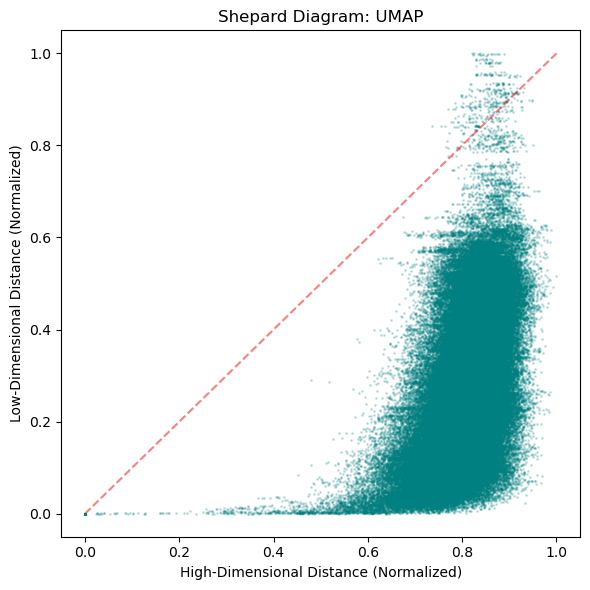

Saved: sentence-transformers/all-MiniLM-L6-v2_results/shepard_rcv1_umap.png


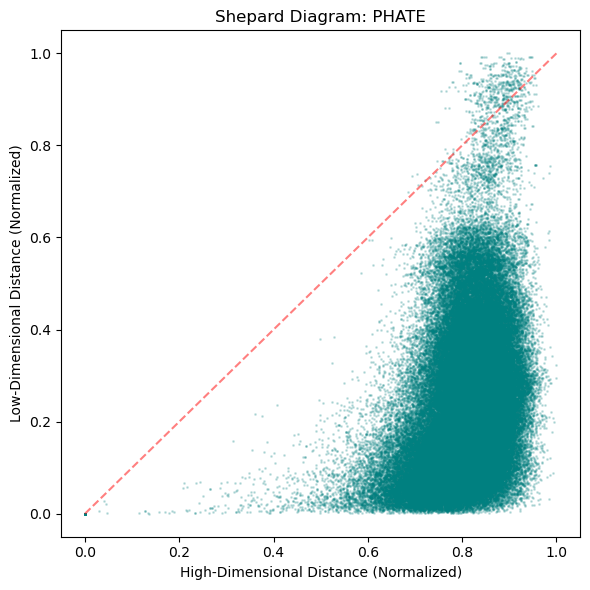

Saved: sentence-transformers/all-MiniLM-L6-v2_results/shepard_rcv1_phate.png


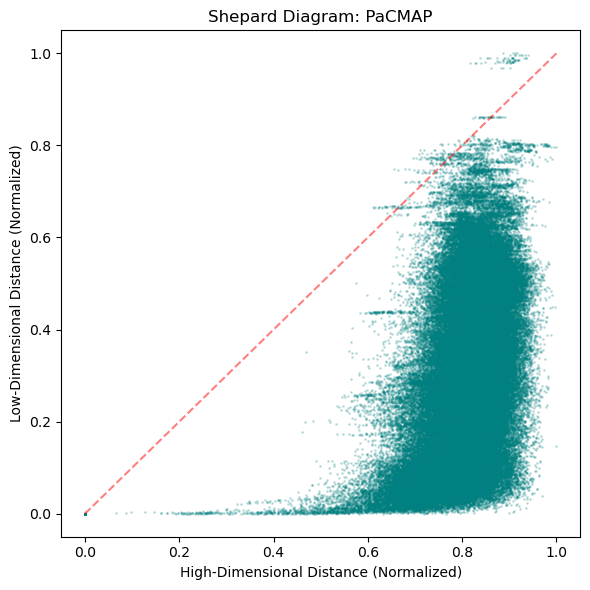

Saved: sentence-transformers/all-MiniLM-L6-v2_results/shepard_rcv1_pacmap.png


In [9]:
def plot_shepard(x_high, x_low, name, sample_size=500):
    indices = np.random.choice(len(x_high), min(sample_size, len(x_high)), replace=False)

    d_high = pairwise_distances(x_high[indices]).flatten()
    d_low  = pairwise_distances(x_low[indices]).flatten()

    d_high = d_high / np.max(d_high)
    d_low  = d_low  / np.max(d_low)

    plt.figure(figsize=(6, 6))
    plt.scatter(d_high, d_low, alpha=0.1, s=1, color='teal')
    plt.plot([0, 1], [0, 1], color='red', linestyle='--', alpha=0.5)
    plt.title(f"Shepard Diagram: {name}")
    plt.xlabel("High-Dimensional Distance (Normalized)")
    plt.ylabel("Low-Dimensional Distance (Normalized)")
    plt.tight_layout()

    filename = os.path.join(results_dir, f"shepard_{dataset}_{name.lower()}.png")
    plt.savefig(filename, dpi=300)
    plt.show()
    return filename

for name, x_low_2d in reductions.items():
    f = plot_shepard(x_high_sub, x_low_2d, name)
    print(f"Saved: {f}")

## 6. Results

Results using `all-MiniLM-L6-v2` embeddings projected natively to 2D. DEMaP uses k=5 neighbors; disconnected pairs set to 1+max distance.

| Dataset | Method | Trustworthiness | Continuity | Spearman | DEMaP |
|---------|--------|----------------|------------|----------|-------|
| RCV1 | PCA | 0.7781 | 0.8913 | 0.3965 | 0.4687 |
| RCV1 | UMAP | 0.9563 | 0.9442 | 0.4863 | 0.6847 |
| RCV1 | PHATE | 0.7979 | 0.9035 | 0.3725 | 0.6453 |
| RCV1 | PaCMAP | 0.9360 | 0.9333 | 0.4218 | 0.6514 |
| arXiv | PCA | 0.7606 | 0.8832 | 0.4858 | 0.4665 |
| arXiv | UMAP | 0.9414 | 0.9290 | 0.5430 | 0.6406 |
| arXiv | PHATE | 0.7988 | 0.8971 | 0.5796 | 0.6243 |
| arXiv | PaCMAP | 0.9051 | 0.9274 | 0.5784 | 0.6442 |
| Amazon | PCA | 0.7399 | 0.8523 | 0.3708 | 0.3605 |
| Amazon | UMAP | 0.9164 | 0.9152 | 0.4400 | 0.5482 |
| Amazon | PHATE | 0.7776 | 0.8833 | 0.4184 | 0.5123 |
| Amazon | PaCMAP | 0.8645 | 0.8992 | 0.3964 | 0.4788 |
| DBpedia | PCA | 0.7116 | 0.8563 | 0.3095 | 0.2374 |
| DBpedia | UMAP | 0.9706 | 0.9371 | 0.2967 | 0.5000 |
| DBpedia | PHATE | 0.8087 | 0.9068 | 0.2244 | 0.4385 |
| DBpedia | PaCMAP | 0.9353 | 0.9325 | 0.2585 | 0.4501 |
| WoS | PCA | 0.7866 | 0.8850 | 0.5444 | 0.5760 |
| WoS | UMAP | 0.9504 | 0.9434 | 0.5313 | 0.7099 |
| WoS | PHATE | 0.8505 | 0.9207 | 0.5438 | 0.7024 |
| WoS | PaCMAP | 0.9102 | 0.9434 | 0.5289 | 0.6892 |

## 7. Discussion

**UMAP and PaCMAP consistently preserve local neighborhood structure better than PCA and PHATE:** Trustworthiness scores for UMAP (0.91-0.97) and PaCMAP (0.86-0.94) are well above PCA (0.71-0.79) and PHATE (0.78-0.85) across all datasets. Optimization-based methods pack clusters tightly in 2D, which keeps local neighborhoods intact.

**UMAP leads on DEMaP across most datasets, with PHATE and PaCMAP close behind:** UMAP DEMaP ranges from 0.50 to 0.71, followed by PaCMAP (0.44-0.69) and PHATE (0.44-0.70). PCA is consistently the weakest (0.24-0.58), reflecting its inability to capture nonlinear manifold structure.

**WoS produces the highest scores across all metrics:** UMAP DEMaP on WoS reaches 0.71, the highest of any dataset. Academic papers organized by field likely form a cleaner and more separable topic structure compared to news articles (RCV1) or product reviews (Amazon).

**DBpedia shows a divergence between local and global structure preservation:** UMAP achieves the highest Trustworthiness on DBpedia (0.97) but one of the lowest Spearman scores (0.30). This is a known UMAP behavior: it aggressively preserves local clusters at the cost of global distances, compressing inter-cluster distances in a way that breaks Spearman rank correlation while still maintaining neighborhood integrity.

**PHATE is competitive on DEMaP despite lower Trustworthiness:** PHATE is designed for manifold and trajectory structure rather than local neighborhoods. On arXiv, PHATE leads on Spearman (0.58) while trailing UMAP on Trustworthiness (0.80 vs 0.94).

**Shepard diagrams complement the scalar metrics:** they show how each method distorts the full distance distribution. Even when scalar scores are similar across methods, the Shepard plots reveal distinct patterns in how each method handles different distance ranges.